# 02 — Gym Environment Tutorial
**(Notebook 2 / 5 — requires `01_dataset_generation.ipynb` to be run first)**

This notebook provides a step-by-step guide to understanding the quantum circuit gymnasium environment. We'll start simple with a single circuit and gradually explore all the components.

1. **Creating a simple dataset** — Start with just one circuit to understand the basics (in-memory only, not saved)
2. **Understanding observations** — How the agent "sees" the circuit (sliding window)
3. **Understanding actions** — How the agent applies noise channels
4. **Understanding rewards** — How we measure the quality of noise predictions
5. **Complete episodes** — Put it all together
6. **Multi-qubit dataset** — Load the canonical 3-qubit dataset from `01_dataset_generation.ipynb`

## 1. Setup and Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qibo import Circuit, gates

from rlnoise.config import (
    DatasetConfig,
    NoiseConfig,
    GateSpecificNoise,
    GymEnvConfig,
    RewardConfig,
)
from rlnoise.dataset import DatasetGenerator
from rlnoise.circuit_encoder import CircuitEncoder
from rlnoise.gym_env import QuantumCircuitEnv

# Set random seed for reproducibility
np.random.seed(42)

## 2. Start Simple: Create a Dataset with ONE Circuit

Let's begin with just one circuit to understand the basics. We'll create a simple 1-qubit circuit with a few gates.

In [2]:
# Step 1: Configure the dataset - just 1 circuit, 1 qubit, 5 moments
dataset_config = DatasetConfig(
    n_circuits=1,           # Start with just ONE circuit
    qubits=1,               # One qubit to keep it simple
    moments=6,              # 6 gates
    primitive_gates=["rx", "rz"],  # Only RX and RZ gates
    clifford=True,          # Generate valid quantum circuits
)

# Step 2: Configure noise - depolarizing and damping on both gates
noise_config = NoiseConfig(
    noise_list=[
        GateSpecificNoise(gate="rx", noise_channel="depolarizing", noise_parameter=0.02),
        GateSpecificNoise(gate="rz", noise_channel="depolarizing", noise_parameter=0.02),
        GateSpecificNoise(gate="rx", noise_channel="damping", noise_parameter=0.01),
        GateSpecificNoise(gate="rz", noise_channel="damping", noise_parameter=0.01),
    ]
)

# Step 3: Generate the dataset
generator = DatasetGenerator(dataset_config, noise_config)
dataset = generator.generate(verbose=True)

print(f"\nCircuit representation (no noise):\n")
print(dataset.circuits[0])
# For more information about the circuit representation look at the dataset_generation tutorial notebook.

[Qibo 0.2.23|INFO|2026-04-21 08:27:35]: Using numpy backend on /CPU:0


Generating 1 circuits...
Applying noise model...
Encoding circuits...
Dataset generated.

Circuit representation (no noise):

[[[1.0 0.0 0.0 0.75 0.0 0.0 0.0 0.0]]

 [[0.0 1.0 0.0 0.5 0.0 0.0 0.0 0.0]]

 [[0.0 1.0 0.0 0.5 0.0 0.0 0.0 0.0]]

 [[0.0 1.0 0.0 0.75 0.0 0.0 0.0 0.0]]

 [[1.0 0.0 0.0 0.5 0.0 0.0 0.0 0.0]]

 [[1.0 0.0 0.0 0.75 0.0 0.0 0.0 0.0]]]


## 3. Create the Environment

Now let's create the gymnasium environment. We need:
1. The dataset
2. A circuit encoder (to convert between arrays and circuits)
3. Environment configuration (how the agent interacts)
4. Reward configuration (how we measure success)

In [3]:
# Step 1: Create circuit encoder, define the native gates (use the default encoding_dim = 8)
encoder = CircuitEncoder(
    primitive_gates=["rx", "rz"],
)

# Step 2: Configure environment behavior
env_config = GymEnvConfig(
    kernel_size=3,                      # Sliding window size (must be odd)
    action_space_max_value=0.1,         # Maximum noise parameter value per channel
    val_split=0.0,                      # No validation split (only 1 circuit)
    enable_only_depolarizing=False,     # Allow all noise types
)

# Step 3: Configure reward function
reward_config = RewardConfig(
    metric="trace",                     # Use trace distance metric
    function="inverted_squared",        # Transform: 1/(alpha * distance^2)
    alpha=20.0,                         # Scaling factor
)

# Step 4: Create the environment
env = QuantumCircuitEnv(
    dataset=dataset,
    encoder=encoder,
    env_config=env_config,
    reward_config=reward_config,
)

print(env)

QuantumCircuitEnv:
  Dataset:
    circuits: 1 (1 train, 0 val)
    qubits: 1
  Encoder:
    primitive_gates: ['rx', 'rz']
  Environment:
    observation_space: (8, 1, 3)
    action_space: (1, 4)
    kernel_size: 3
    action_max: 0.1
    only_depolarizing: False
  Reward:
    metric: trace
    function: inverted_squared
    alpha: 20.0


## 4. How Observations Work: The Sliding Window

The agent doesn't see the whole circuit at once. Instead, it sees a "sliding window" of 3 moments (like looking through a small window as you move along the circuit).

In [4]:
# Reset environment to start an episode
obs, info = env.reset()

print(f"Observation space shape: {obs.shape}")
print(f"  - {obs.shape[0]} encoding features")
print(f"  - {obs.shape[1]} qubit(s)")
print(f"  - {obs.shape[2]} kernel size")

print("\nObservation at position 0:")
print("Zero padding plus the first two moments.")
print(obs)

print(f"\nCurrent position: {info}")


Observation space shape: (8, 1, 3)
  - 8 encoding features
  - 1 qubit(s)
  - 3 kernel size

Observation at position 0:
Zero padding plus the first two moments.
[[[0.   1.   0.  ]]

 [[0.   0.   1.  ]]

 [[0.   0.   0.  ]]

 [[0.   0.75 0.5 ]]

 [[0.   0.   0.  ]]

 [[0.   0.   0.  ]]

 [[0.   0.   0.  ]]

 [[0.   0.   0.  ]]]

Current position: {'circuit_idx': 0, 'circuit_length': 6}


We'll take a step with a zero action (no noise applied) to see how the sliding window moves forward through the circuit. The window will shift from observing moments [0, 1, 2] to moments [1, 2, 3] (the 0 moment is the zero padding).

In [5]:
# Take a step with zero action (no noise applied)
zero_action = np.zeros((env.n_qubits, 4))

obs_next, reward, terminated, truncated, info = env.step(zero_action)

print(f"Position after step: {info['position']}")

print("The sliding window has moved forward by 1 moment")
print(obs_next)

print(f"\nReward at this step: {reward} (rewards are only given at terminal state)")
print(f"Terminated: {terminated}")

Position after step: 1
The sliding window has moved forward by 1 moment
[[[1.   0.   0.  ]]

 [[0.   1.   1.  ]]

 [[0.   0.   0.  ]]

 [[0.75 0.5  0.5 ]]

 [[0.   0.   0.  ]]

 [[0.   0.   0.  ]]

 [[0.   0.   0.  ]]

 [[0.   0.   0.  ]]]

Reward at this step: 0.0 (rewards are only given at terminal state)
Terminated: False


## 5. How Actions Work: Applying Noise Parameters

The agent's action specifies noise parameters to apply at the current position (the middle of the sliding window).

In [6]:
# Action space shape: (n_qubits, 4)
# For 1 qubit: (1, 4)
# 4 noise parameters per qubit:
#   [0] epsilon_x (coherent X error)
#   [1] epsilon_z (coherent Z error)
#   [2] reset/damping probability
#   [3] depolarizing lambda

print("Action space details:")
print(f"  Shape: {env.action_space.shape}")
print(f"  Range: [{env.action_space.low[0,0]:.1f}, {env.action_space.high[0,0]:.1f}]")
print(f"  Scaled by: {env_config.action_space_max_value}")
print(f"\n  Index 0: Coherent X error (epsilon_x)")
print(f"  Index 1: Coherent Z error (epsilon_z)")
print(f"  Index 2: Damping/reset probability")
print(f"  Index 3: Depolarizing lambda")

# Sample a random action
random_action = env.action_space.sample()
print(f"\nRandom action example:")
print(random_action)
print(f"\nThis means: Apply these noise values to qubit 0:")
print(f"  epsilon_x = {random_action[0,0]:.4f}")
print(f"  epsilon_z = {random_action[0,1]:.4f}")
print(f"  damping   = {random_action[0,2]:.4f}")
print(f"  depol     = {random_action[0,3]:.4f}")

Action space details:
  Shape: (1, 4)
  Range: [0.0, 1.0]
  Scaled by: 0.1

  Index 0: Coherent X error (epsilon_x)
  Index 1: Coherent Z error (epsilon_z)
  Index 2: Damping/reset probability
  Index 3: Depolarizing lambda

Random action example:
[[0.03340139 0.50135875 0.3146231  0.5882611 ]]

This means: Apply these noise values to qubit 0:
  epsilon_x = 0.0334
  epsilon_z = 0.5014
  damping   = 0.3146
  depol     = 0.5883


### 5.1. Take an Action and See What Happens

In [7]:
#First let's reset the environment to start from the initial state again
obs, info = env.reset()

dep_noise = 0.3  # This will be scaled by action_max_value=0.1 to 0.03

# Let's apply a specific action: depolarizing noise
action = np.zeros((1, 4), dtype=np.float32)
action[0, 3] = dep_noise  # Set depolarizing to 0.3 (will be scaled by action_max=0.1)

print("Action we're taking:")
print(action)
print(f"This will add depolarizing noise of: {dep_noise} * {env_config.action_space_max_value} = {dep_noise * env_config.action_space_max_value}")

# Take the action
obs_next, reward, terminated, truncated, info = env.step(action)

# Show the whole circuit after the action amd the new observation
print("\nNew circuit after applying depolarizing noise (on the first circuit moment):")
print(env.current_circuit)

print("\nNew observation:")
print(obs_next)

Action we're taking:
[[0.  0.  0.  0.3]]
This will add depolarizing noise of: 0.3 * 0.1 = 0.03

New circuit after applying depolarizing noise (on the first circuit moment):
[[[1.0 0.0 0.0 0.75 np.float32(0.030000001) np.float32(0.0)
   np.float32(0.0) np.float32(0.0)]]

 [[0.0 1.0 0.0 0.5 0.0 0.0 0.0 0.0]]

 [[0.0 1.0 0.0 0.5 0.0 0.0 0.0 0.0]]

 [[0.0 1.0 0.0 0.75 0.0 0.0 0.0 0.0]]

 [[1.0 0.0 0.0 0.5 0.0 0.0 0.0 0.0]]

 [[1.0 0.0 0.0 0.75 0.0 0.0 0.0 0.0]]]

New observation:
[[[1.   0.   0.  ]]

 [[0.   1.   1.  ]]

 [[0.   0.   0.  ]]

 [[0.75 0.5  0.5 ]]

 [[0.03 0.   0.  ]]

 [[0.   0.   0.  ]]

 [[0.   0.   0.  ]]

 [[0.   0.   0.  ]]]


### 5.2. Repeat until end of episode

Now let's run through an entire episode, applying a consistent depolarizing noise of 0.03 after every gate. We'll then convert the final circuit to a Qibo circuit to see the complete noisy circuit.

In [8]:
# Run through the entire episode
terminated = False
while not terminated:
    obs, reward, terminated, truncated, info = env.step(action)  # Keep applying the same action for simplicity
    
print(f"Final reward (not relevant now): {reward}\n")

# Show the final circuit array (with noise parameters added)
print("Final circuit array (showing depolarizing added at each position):")
print(env.current_circuit)  # Index 4 is depolarizing channel

# Convert to Qibo circuit to see the actual gate sequence
print("\n" + "="*70)
print("Final Qibo Circuit with Noise:")
print("="*70)
final_circuit = encoder.array_to_circuit(env.current_circuit)
print(final_circuit.draw())

Final reward (not relevant now): 220.11337822987096

Final circuit array (showing depolarizing added at each position):
[[[1.0 0.0 0.0 0.75 np.float32(0.030000001) np.float32(0.0)
   np.float32(0.0) np.float32(0.0)]]

 [[0.0 1.0 0.0 0.5 np.float32(0.030000001) np.float32(0.0)
   np.float32(0.0) np.float32(0.0)]]

 [[0.0 1.0 0.0 0.5 np.float32(0.030000001) np.float32(0.0)
   np.float32(0.0) np.float32(0.0)]]

 [[0.0 1.0 0.0 0.75 np.float32(0.030000001) np.float32(0.0)
   np.float32(0.0) np.float32(0.0)]]

 [[1.0 0.0 0.0 0.5 np.float32(0.030000001) np.float32(0.0)
   np.float32(0.0) np.float32(0.0)]]

 [[1.0 0.0 0.0 0.75 np.float32(0.030000001) np.float32(0.0)
   np.float32(0.0) np.float32(0.0)]]]

Final Qibo Circuit with Noise:
0: ─RZ─D─RX─D─RX─D─RX─D─RZ─D─RZ─D─
None


## 6. Rewards

The reward is computed ONLY at the terminal state (end of episode). It measures how well the noisy circuit matches the target noisy behavior.

In [9]:
from rlnoise.reward import RewardFunction

# The reward function has two components:
# 1. A METRIC: measures distance between density matrices
# 2. A TRANSFORM: converts distance to reward (higher is better)

print("Our reward configuration:")
print(f"  Metric: {reward_config.metric}")
print(f"  Function: {reward_config.function}")
print(f"  Alpha: {reward_config.alpha}")

print("\n Available metrics:")
print("  - 'trace': Trace distance (0 to 1)")
print("  - 'fidelity': 1 - fidelity (0 to 1)")
print("  - 'mse': Mean squared error")
print("  - 'mae': Mean absolute error")

print("\n Available transforms:")
print("  - 'linear': -alpha * distance")
print("  - 'log': -log(alpha * distance)")
print("  - 'inverted': 1 / (alpha * distance)")
print("  - 'inverted_squared': 1 / (alpha * distance^2)")

print(f"\n With our settings:")
print(f"   If distance = 0.01, reward = 1 / (20 * 0.01^2 + 1e-10) = 1 / 0.002 = 500")
print(f"   If distance = 0.1,  reward = 1 / (20 * 0.1^2 + 1e-10)  = 1 / 0.2   = 5")

Our reward configuration:
  Metric: trace
  Function: inverted_squared
  Alpha: 20.0

 Available metrics:
  - 'trace': Trace distance (0 to 1)
  - 'fidelity': 1 - fidelity (0 to 1)
  - 'mse': Mean squared error
  - 'mae': Mean absolute error

 Available transforms:
  - 'linear': -alpha * distance
  - 'log': -log(alpha * distance)
  - 'inverted': 1 / (alpha * distance)
  - 'inverted_squared': 1 / (alpha * distance^2)

 With our settings:
   If distance = 0.01, reward = 1 / (20 * 0.01^2 + 1e-10) = 1 / 0.002 = 500
   If distance = 0.1,  reward = 1 / (20 * 0.1^2 + 1e-10)  = 1 / 0.2   = 5


### 6.1. Testing the Reward Function

Perfect match (identical density matrices):
  mse: 0.000000
  mae: 0.000000
  trace_distance: 0.000000
  fidelity: 1.000000


Different states (|0⟩ vs maximally mixed):
  mse: 0.125000
  mae: 0.250000
  trace_distance: 0.500000
  fidelity: 0.500000


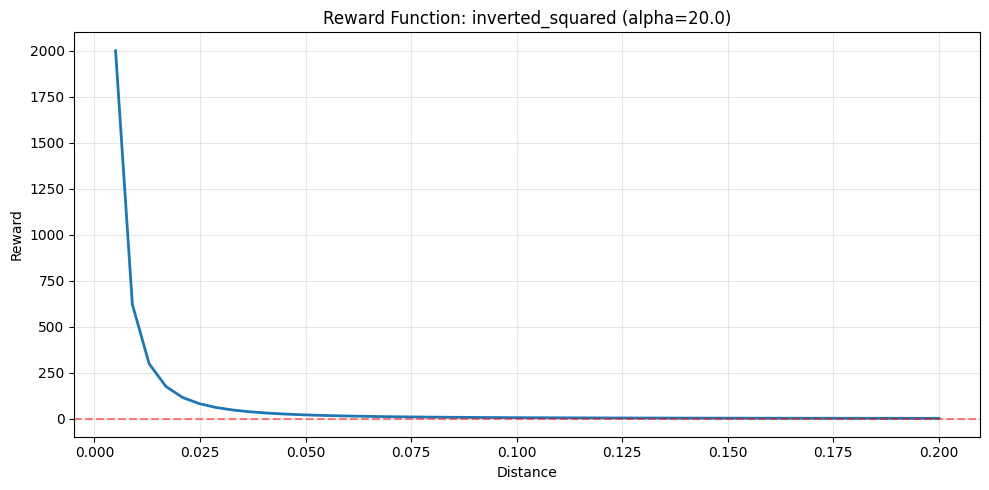

In [10]:
# Let's test the reward function with example density matrices
reward_fn = RewardFunction(reward_config)

# Create two example density matrices
# Perfect match (identical)
dm1 = np.array([[1, 0], [0, 0]], dtype=complex)  # Pure state |0⟩
dm2 = np.array([[1, 0], [0, 0]], dtype=complex)  # Same state

# Compute metrics
metrics_perfect = reward_fn.evaluate(dm1, dm2)

print("Perfect match (identical density matrices):")
for key, value in metrics_perfect.items():
    print(f"  {key}: {value:.6f}")

print("\n" + "="*50)

# Different states
dm3 = np.array([[0.5, 0], [0, 0.5]], dtype=complex)  # Mixed state

metrics_different = reward_fn.evaluate(dm1, dm3)

print("\nDifferent states (|0⟩ vs maximally mixed):")
for key, value in metrics_different.items():
    print(f"  {key}: {value:.6f}")

# Visualize reward vs distance
distances = np.linspace(0.005, 0.2, 50)
rewards = [1.0 / (reward_config.alpha * d**2 + 1e-10) for d in distances]

plt.figure(figsize=(10, 5))
plt.plot(distances, rewards, linewidth=2)
plt.xlabel('Distance')
plt.ylabel('Reward')
plt.title(f'Reward Function: {reward_config.function} (alpha={reward_config.alpha})')
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='r', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 7. Complete Episode

Now let's run a complete episode from start to finish. We'll step through the circuit, apply actions, and get the final reward.

In [11]:
# Reset the environment
obs, info = env.reset()

print(f"Starting episode with circuit {info['circuit_idx']}")
print(f"Circuit length: {info['circuit_length']} moments")
print(f"Need to take {info['circuit_length']} actions\n")

# Store trajectory
observations = [obs]
actions_taken = []
rewards_received = []

# Run episode with random actions
terminated = False
step = 0

while not terminated:
    # Sample random action
    action = env.action_space.sample()
    
    # Take step
    obs, reward, terminated, truncated, info = env.step(action)
    
    # Store
    observations.append(obs)
    actions_taken.append(action)
    rewards_received.append(reward)
    
    print(f"Step {step}: Position {step}, Reward = {reward:.6f}, Terminated = {terminated}")
    step += 1

print(f"Episode finished!")



Starting episode with circuit 0
Circuit length: 6 moments
Need to take 6 actions

Step 0: Position 0, Reward = 0.000000, Terminated = False
Step 1: Position 1, Reward = 0.000000, Terminated = False
Step 2: Position 2, Reward = 0.000000, Terminated = False
Step 3: Position 3, Reward = 0.000000, Terminated = False
Step 4: Position 4, Reward = 0.000000, Terminated = False
Step 5: Position 5, Reward = 1.713041, Terminated = True
Episode finished!


In [12]:
# The environment stores the circuit with all noise applied
final_circuit_array = env.current_circuit

print("Final circuit encoding with noise:")
print("Shape:", final_circuit_array.shape)
print("\nNoise parameters (indices 4-7) at each moment:")
print("Moment | Depol  | Damp   | Coh-Z  | Coh-X")
print("-" * 50)
for i in range(final_circuit_array.shape[0]):
    noise = final_circuit_array[i, 0, 4:8]
    print(f"  {i}    | {noise[0]:.4f} | {noise[1]:.4f} | {noise[2]:.4f} | {noise[3]:.4f}")



Final circuit encoding with noise:
Shape: (6, 1, 8)

Noise parameters (indices 4-7) at each moment:
Moment | Depol  | Damp   | Coh-Z  | Coh-X
--------------------------------------------------
  0    | 0.0372 | 0.0867 | 0.0505 | 0.0205
  1    | 0.0274 | 0.0733 | 0.0215 | 0.0958
  2    | 0.0342 | 0.0015 | 0.0149 | 0.0290
  3    | 0.0004 | 0.0819 | 0.0395 | 0.0133
  4    | 0.0188 | 0.0543 | 0.0749 | 0.0652
  5    | 0.0050 | 0.0747 | 0.0222 | 0.0557


Now let's apply the correct noise, expecting a much higher reward

In [13]:
# Reset the environment
obs, info = env.reset()

# Store trajectory
observations = [obs]
actions_taken = []
rewards_received = []

# Run episode with random actions
terminated = False
step = 0

while not terminated:
    # For the action we use the original noise parameters of the noise model
    action = np.zeros((1, 4), dtype=np.float32)
    action[0, 3] = 0.2  # Set depolarizing to 0.02
    action[0, 2] = 0.1  # Set depolarizing to 0.01
    
    # Take step
    obs, reward, terminated, truncated, info = env.step(action)
    
    # Store
    observations.append(obs)
    actions_taken.append(action)
    rewards_received.append(reward)
    
    print(f"Step {step}: Position {step}, Reward = {reward:.6f}, Terminated = {terminated}")
    step += 1

print(f"Episode finished!")

Step 0: Position 0, Reward = 0.000000, Terminated = False
Step 1: Position 1, Reward = 0.000000, Terminated = False
Step 2: Position 2, Reward = 0.000000, Terminated = False
Step 3: Position 3, Reward = 0.000000, Terminated = False
Step 4: Position 4, Reward = 0.000000, Terminated = False
Step 5: Position 5, Reward = 999830008.625847, Terminated = True
Episode finished!


## 8. Multi-Qubit Complete Dataset

Now that you understand the basics, let's load the canonical 3-qubit dataset generated in `01_dataset_generation.ipynb` and explore it.

### 8.1. Load the 3-Qubit Dataset

In [14]:
from rlnoise.dataset import CircuitDataset
from pathlib import Path

DATASET_3Q_PATH = Path("datasets/dataset_3q.npz")
if not DATASET_3Q_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at '{DATASET_3Q_PATH}'.\n"
        "Please run '01_dataset_generation.ipynb' (Section 4) first to generate it."
    )

dataset_3q = CircuitDataset.load(str(DATASET_3Q_PATH))
print(f"Loaded 3-qubit dataset from '{DATASET_3Q_PATH}'")
print(dataset_3q)

Loaded 3-qubit dataset from 'datasets\dataset_3q.npz'

  CircuitDataset
    - Circuits:            800
    - Qubits:              3
    - Moments (depth):     31
    - Encoding dimension:  8
    - Circuit shape:       variable (sample: (31, 3, 8))


### 8.2. Create Environment for Multi-Circuit Dataset

In [15]:
# Create encoder for 3-qubit circuits with all gates in the dataset
encoder_3q = CircuitEncoder(
    primitive_gates=["rx", "rz", "cz"],  # Common gates for 3-qubit circuits
)

# Configure environment for 3-qubit circuits
env_config_3q = GymEnvConfig(
    kernel_size=3,
    action_space_max_value=0.1,
    val_split=0.0,  # Use all circuits for training
    enable_only_depolarizing=False,
)

# Configure reward function
reward_config_3q = RewardConfig(
    metric="trace",
    function="inverted_squared",
    alpha=20.0,
)

# Create the environment with the 3-qubit dataset
env_3q = QuantumCircuitEnv(
    dataset=dataset_3q,
    encoder=encoder_3q,
    env_config=env_config_3q,
    reward_config=reward_config_3q,
)

print(f"Action space shape: {env_3q.action_space.shape}")
print(f"Observation space shape: {env_3q.observation_space.shape}")

Action space shape: (3, 4)
Observation space shape: (8, 3, 3)


### 8.3. Play Multiple Episodes with Random Actions

Let's run a few episodes to demonstrate that each episode selects a different circuit randomly.

In [16]:
# Play 5 episodes with random actions
n_episodes = 5
episode_results = []

for episode in range(n_episodes):
    obs, info = env_3q.reset()
    circuit_idx = env_3q.current_circuit_idx
    circuit_moments = env_3q.current_circuit.shape[0]
    
    print(f"\nEPISODE {episode + 1}")
    print(f"Selected Circuit Index: {circuit_idx}")
    
    episode_rewards = []
    step = 0
    terminated = False
    
    while not terminated:
        # Take random action
        action = env_3q.action_space.sample()
        obs_next, reward, terminated, truncated, info = env_3q.step(action)
        episode_rewards.append(reward)
        step += 1
    
    # Calculate episode statistics
    total_reward = sum(episode_rewards)
    
    print(f"Episode Summary:")
    print(f"  Total steps: {step}")
    print(f"  Total reward: {total_reward:.4f}")
    
    # Store the final noisy circuit array for later visualization
    final_circuit_array = env_3q.current_circuit.copy()
    
    episode_results.append({
        'episode': episode + 1,
        'circuit_idx': circuit_idx,
        'circuit_moments': circuit_moments,
        'total_reward': total_reward,
        'final_circuit_array': final_circuit_array
    })


EPISODE 1
Selected Circuit Index: 521
Episode Summary:
  Total steps: 35
  Total reward: 0.5762

EPISODE 2
Selected Circuit Index: 446
Episode Summary:
  Total steps: 20
  Total reward: 0.3432

EPISODE 3
Selected Circuit Index: 235
Episode Summary:
  Total steps: 20
  Total reward: 0.4724

EPISODE 4
Selected Circuit Index: 452
Episode Summary:
  Total steps: 43
  Total reward: 0.9231

EPISODE 5
Selected Circuit Index: 650
Episode Summary:
  Total steps: 51
  Total reward: 0.6005


Let's look at the actual Qibo circuits that were generated with the random noise parameters applied.

In [17]:
episode_to_show = 0

result = episode_results[episode_to_show]

print(f"\n{'─'*70}")
print(f"EPISODE {result['episode']} - Circuit Index {result['circuit_idx']}")
print(f"{'─'*70}")

# Get the original circuit from the dataset (without noise)
original_circuit_array = dataset_3q.circuits[result['circuit_idx']]
original_circuit = encoder_3q.array_to_circuit(original_circuit_array)

print("\nORIGINAL CIRCUIT (Without Noise)")
print(original_circuit.draw())

# Convert the final circuit array (with noise) back to a Qibo circuit
reconstructed_circuit = encoder_3q.array_to_circuit(result['final_circuit_array'])

print("\nCIRCUIT WITH NOISE APPLIED (Random actions)")
print(reconstructed_circuit.draw())


──────────────────────────────────────────────────────────────────────
EPISODE 1 - Circuit Index 521
──────────────────────────────────────────────────────────────────────

ORIGINAL CIRCUIT (Without Noise)
0:     ─RZ─RZ─RX─────────────────────────────────────────────────────o─RZ─RX─ ...
1:     ─RX─RZ─RX─o─RZ─RX─RZ─RX─o─RZ─RX─RZ─RX─o─RZ─RX─o─RZ─RX─o─RZ─RX─Z─────── ...
2:     ─RX─RZ─RX─Z─RZ─RX───────Z─────────────Z─RZ─RX─Z─RZ─RX─Z─RZ─RX───────── ...

0: ... RZ─RZ─RX─o─RZ─RX─RZ─o───────
1: ... ─────────Z──────────|───────
2: ... ────────────────────Z─RZ─RX─
None

CIRCUIT WITH NOISE APPLIED (Random actions)
0:     ─RZ─RX─RZ─R─D─RZ─RX─RZ─R─D─RX─RX─RZ─R─D─────────────RX─RZ─R──D─RX─RZ─R ...
1:     ─RX─RX─RZ─R─D─RZ─RX─RZ─R─D─RX─RX─RZ─R─D─o─RX─RZ─R─D─RZ─RX─RZ─R─D──RX─R ...
2:     ─RX─RX─RZ─R─D─RZ─RX─RZ─R─D─RX─RX─RZ─R─D─Z─RX─RZ─R─D─RZ─RX─RZ─R─D──RX─R ...

0: ... ──D──RX─RZ─R──D──RX─RZ─R──D──RX─RZ─R─D─────────────RX─RZ─R──D─RX─RZ─R─ ...
1: ... X─RZ─R──D──RZ─RX─RZ─R──D──RX─RX─RZ─R─D─o─RX─RZ─R─D─R